In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import joblib

In [35]:
df = pd.read_csv('../updated_marketing_campaign_dataset.csv')
# df.head()
print(df.columns)

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Duration_Days', 'Target_Gender', 'Target_Age'],
      dtype='str')


In [36]:
X = df[['Clicks',
        'Impressions',
        'Engagement_Score',
        'Duration_Days']]

y = df['ROI']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [39]:
predictions = model.predict(X_test)

In [40]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.5027071468121047


In [41]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: -0.0007871627376481172


In [42]:
joblib.dump(model, '../models/roi_model.pkl')

['../models/roi_model.pkl']

In [43]:
sample_data = [[5000, 20000, 75, 45]]

prediction = model.predict(sample_data)

print("Predicted ROI:", prediction[0])

Predicted ROI: 4.774075631696499


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


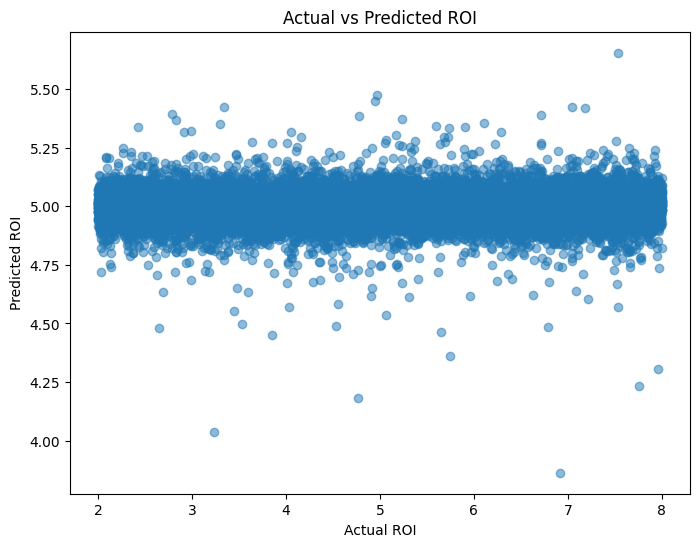

In [44]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.5)

# Labels
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")

# Title
plt.title("Actual vs Predicted ROI")

# Show plot
plt.show()

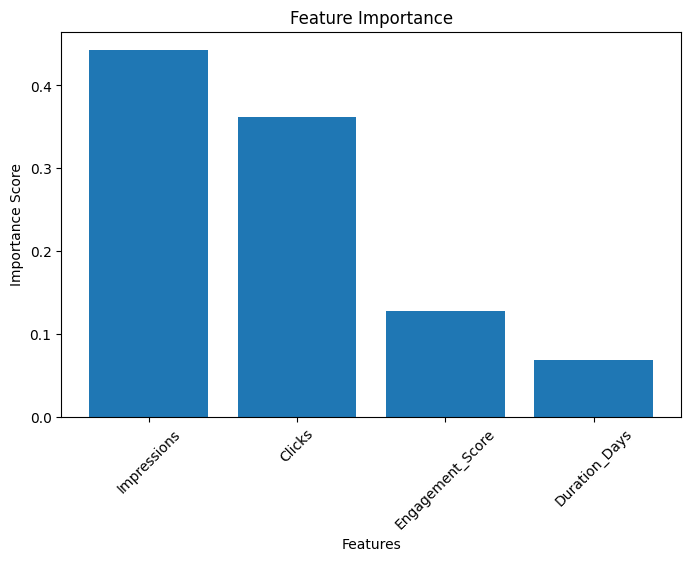

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

# Labels
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

# Rotate labels
plt.xticks(rotation=45)

plt.show()

### This Answers Business Questions 🎯

Like:
- What affects ROI most?
- Clicks or engagement?
- Impressions or duration?

This is REAL business intelligence.

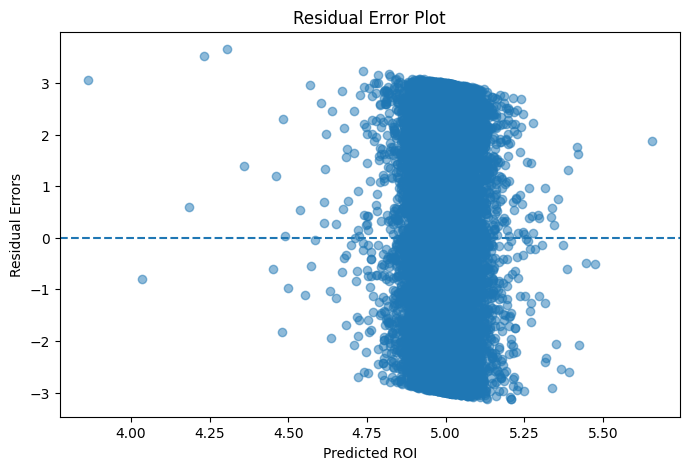

In [46]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter(predictions, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted ROI")
plt.ylabel("Residual Errors")

plt.title("Residual Error Plot")

plt.show()

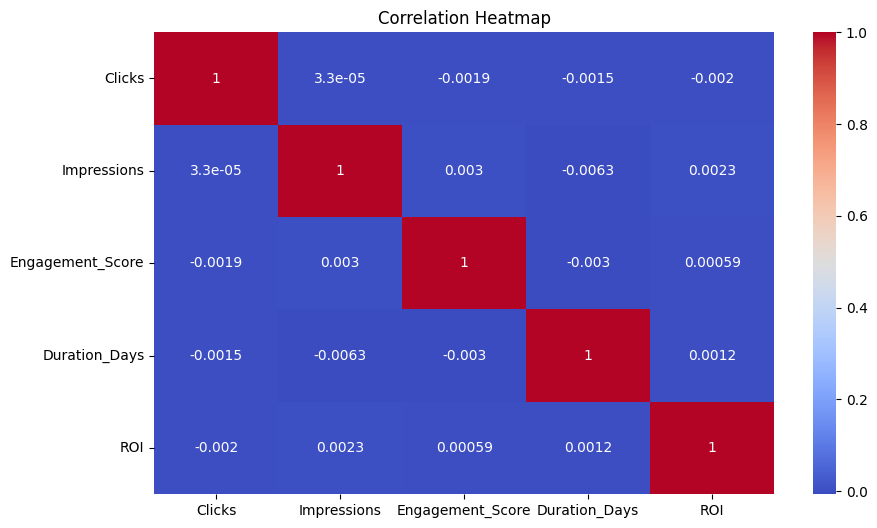

In [47]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df[['Clicks',
        'Impressions',
        'Engagement_Score',
        'Duration_Days',
        'ROI']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

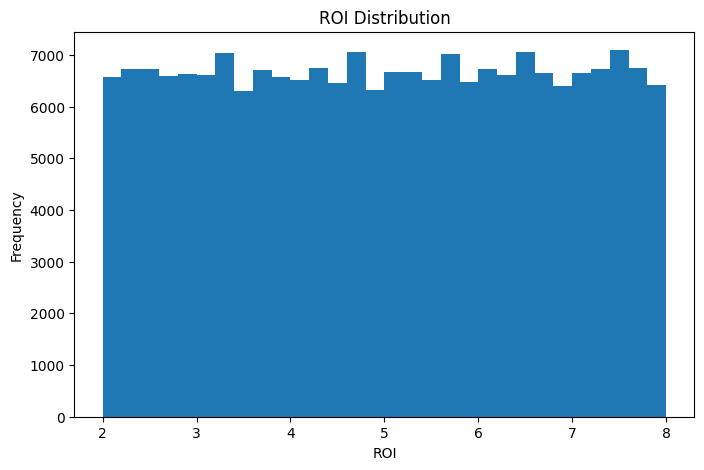

In [48]:
plt.figure(figsize=(8,5))

plt.hist(df['ROI'], bins=30)

plt.title("ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Frequency")

plt.show()

In [49]:
sample_data = pd.DataFrame({
    'Clicks': [5000],
    'Impressions': [20000],
    'Engagement_Score': [75],
    'Duration_Days': [45]
})

prediction = model.predict(sample_data)

print(prediction)

[4.77407563]


In [50]:
df['Success'] = df['ROI'].apply(
    lambda x: 1 if x > 5 else 0
)

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
X = df[['Clicks',
        'Impressions',
        'Engagement_Score',
        'Duration_Days']]

y = df['Success']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.49695


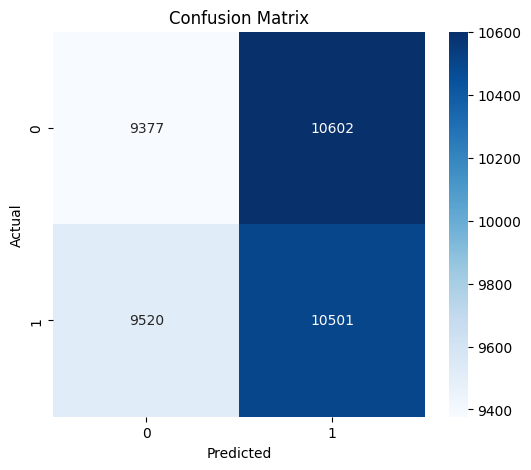

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, predictions)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

# Labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

|                | Predicted Fail | Predicted Success |
| -------------- | -------------- | ----------------- |
| Actual Fail    | Correct        | Wrong             |
| Actual Success | Wrong          | Correct           |


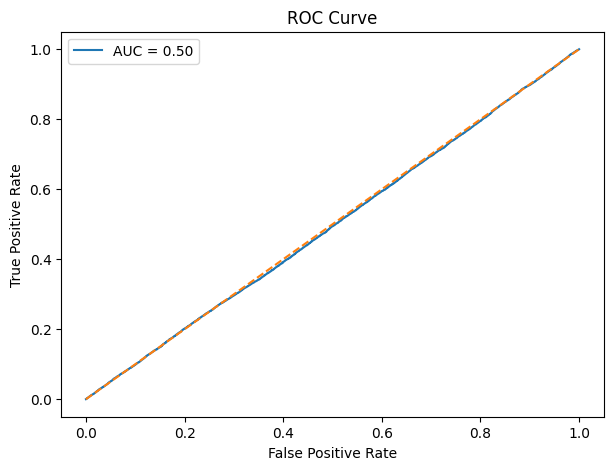

In [57]:
from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

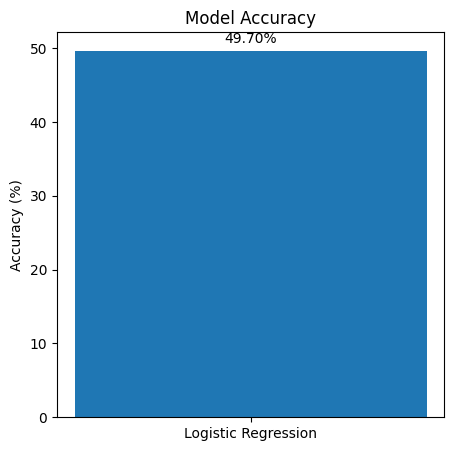

In [59]:
import matplotlib.pyplot as plt

# Accuracy value
accuracy_value = accuracy * 100

# Plot
plt.figure(figsize=(5,5))

plt.bar(
    ['Logistic Regression'],
    [accuracy_value]
)

# Labels
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy")

# Add value on top
plt.text(
    0,
    accuracy_value + 1,
    f"{accuracy_value:.2f}%",
    ha='center'
)

plt.show()